In [1]:
#1
# epilepsy_final = spark.read.parquet('file:/home/o_suchsi/work/Oklahoma State/Priya/epilepsy/epilepsy_072023.parquet')
epilepsy_final = spark.read.parquet('file:/home/o_suchsi/work/Oklahoma State/Priya/epilepsy/epilepsy_072023_removedduplicates.parquet')

In [ ]:
epilepsy_final.show(5)

In [2]:
#2
epilepsy_final.createOrReplaceTempView('epilepsy_lab_final')

In [ ]:
result = spark.sql("SELECT COUNT(EPI) FROM epilepsy_lab_final")

# Retrieve the count value
count = result.first()[0]
print(count)

In [2]:
#3
import pandas as pd
import pyarrow.parquet as pq

In [3]:
#4
# df_pq = pq.read_table('epilepsy_072023.parquet')
df_pq = pq.read_table('epilepsy_072023_removedduplicates.parquet')

OSError: Passed non-file path: epilepsy_072023_removedduplicates.parquet

In [ ]:
epilepsy_final.show

In [5]:
#5
df_pd = epilepsy_final.toPandas()

In [6]:
#6
df_pd

,personid,diagnosis_date,gender,race,conditioncode,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,...,41276-7,4544-3,4548-4,49765-1,6690-2,718-7,77138-6,787-2,789-8,EPI
0,0001b377-b000-449b-a220-e46f27ccf120,,Female,Other_race,1,NaN,8,60,28,9,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,0004c21d-7445-455c-bd10-2e669b968eea,,Female,Other_race,1,NaN,0,7,6,9,...,NaN,43.7,NaN,NaN,NaN,14.1,NaN,89.0,4.90,0
2,0005130a-88e0-448a-bf3d-25eadce357bf,,Male,Other_race,1,NaN,0,0,0,0,...,NaN,39.9,NaN,NaN,12.8,13.9,NaN,90.1,4.43,0
3,000ea644-3bed-430d-940b-b3ff7d25f324,2018-05-04T00:00:00,Female,White,1,85.822581,0,0,0,8,...,NaN,32.9,NaN,NaN,6.6,10.5,NaN,89.2,3.69,0
4,003c1ec7-d723-48e7-9f6e-a332901198fa,2019-09-23T19:00:00+00:00,Male,Other_race,1,78.596214,0,11,6,5,...,NaN,49.9,NaN,NaN,16.8,16.8,NaN,88.0,5.64,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,ffd33154-5e4e-4680-9e73-f2a3d760418f,,Male,Other_race,1,NaN,0,3,2,0,...,NaN,44.3,NaN,NaN,8.0,14.6,NaN,94.1,4.71,0
1266587,ffe21dec-8f5c-4547-bfa6-6714fd2cbc6b,2017-05-13T19:35:00+00:00,Male,Other_race,1,28.604344,0,0,0,0,...,10.0,41.7,NaN,NaN,6.8,14.2,NaN,91.0,4.57,0
1266588,fff621ac-5dec-45cf-bac3-09ce9f3b12ca,2017-06-26T16:51:00.153000+00:00,Female,White,1,60.673930,0,11,0,0,...,NaN,43.2,NaN,NaN,12.2,13.6,NaN,92.5,4.67,0
1266589,fff73b97-3b73-4abd-8ebb-c151f5a1e0a6,2020-06-04T13:29:00+00:00,Female,White,1,58.891295,4,38,0,2,...,NaN,38.1,NaN,NaN,9.8,13.3,NaN,87.4,4.36,0


In [6]:
#7
column_to_drop_1 = 'personid'
df_pd.drop(column_to_drop_1, axis=1, inplace=True)
column_to_drop_2 = 'diagnosis_date'
df_pd.drop(column_to_drop_2, axis=1, inplace=True)
column_to_drop_3 = 'conditioncode'
df_pd.drop(column_to_drop_3, axis=1, inplace=True)
df_pd

,gender,race,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,...,41276-7,4544-3,4548-4,49765-1,6690-2,718-7,77138-6,787-2,789-8,EPI
0,Female,Other_race,NaN,8,60,28,9,3,0,5,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,Female,Other_race,NaN,0,7,6,9,1,5,9,...,NaN,43.7,NaN,NaN,NaN,14.1,NaN,89.0,4.90,0
2,Male,Other_race,NaN,0,0,0,0,0,0,0,...,NaN,39.9,NaN,NaN,12.8,13.9,NaN,90.1,4.43,0
3,Female,White,85.822581,0,0,0,8,0,0,0,...,NaN,32.9,NaN,NaN,6.6,10.5,NaN,89.2,3.69,0
4,Male,Other_race,78.596214,0,11,6,5,0,3,0,...,NaN,49.9,NaN,NaN,16.8,16.8,NaN,88.0,5.64,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,Male,Other_race,NaN,0,3,2,0,0,1,0,...,NaN,44.3,NaN,NaN,8.0,14.6,NaN,94.1,4.71,0
1266587,Male,Other_race,28.604344,0,0,0,0,0,0,0,...,10.0,41.7,NaN,NaN,6.8,14.2,NaN,91.0,4.57,0
1266588,Female,White,60.673930,0,11,0,0,0,0,0,...,NaN,43.2,NaN,NaN,12.2,13.6,NaN,92.5,4.67,0
1266589,Female,White,58.891295,4,38,0,2,1,0,2,...,NaN,38.1,NaN,NaN,9.8,13.3,NaN,87.4,4.36,0


In [7]:
#8
col_names=["718-7", "1751-7", "4544-3","4548-4","6690-2","age_at_diagnosis"]
a=df_pd.columns
for x in col_names:
    print(x)

718-7
1751-7
4544-3
4548-4
6690-2
age_at_diagnosis


In [8]:
#9
age=df_pd[df_pd['age_at_diagnosis']>60]

In [9]:
#10
age["age_at_diagnosis"].mean()

75.60661229751766

In [10]:
#11
df_pd["nN39_0"]

0          1
1          0
2          0
3          2
4          0
          ..
1266586    0
1266587    0
1266588    6
1266589    2
1266590    2
Name: nN39_0, Length: 1266591, dtype: int64

In [11]:
#12
age["race"].value_counts()

Other_race    160850
White          51950
Hispanic       13212
Black           1230
Asian            937
Name: race, dtype: int64

In [12]:
#13
df_pd['age_at_diagnosis'].mean()

43.89650960081415

In [13]:
#14
df_pd["nN39_0"].unique()

array([  1,   0,   2,   5,   3,  12,  21,   4,   7,   8,  15,   9,  10,
        18,  28,   6,  14,  23,  11,  59,  31,  25,  17,  60,  50,  13,
        24,  29,  19,  68,  22,  16,  20,  34,  52,  32,  30,  27,  67,
        47,  43,  35,  53,  39,  93,  44,  26,  40,  37,  56,  33,  61,
        36,  96,  63,  41,  38,  84,  65,  48,  64, 111,  51,  75,  66,
        57,  49,  46,  76,  70,  54, 130,  97,  45,  88,  78, 104,  42,
        94,  73, 152, 100, 128,  77,  72,  86,  85, 121,  74, 189,  55,
        79, 149,  80,  58, 110, 157, 187, 102, 108, 126,  62, 162,  83,
        71, 103, 208, 248,  81,  90, 124, 107,  99,  82,  69,  87,  98,
        91, 112, 134, 120, 178, 113, 125, 148, 150, 140,  89, 143])

In [14]:
#15
import pandas as pd
import numpy as np
from scipy import stats

def stat(df_pd):
    for var_name in col_names:
        df_pd=df_pd.dropna(subset=[var_name])
        #df=df.fillna(df[var_name].mean())
        values = df_pd[var_name].values
        values = df_pd[var_name.strip()].values
        mean = np.mean(values)
        std = np.std(values)
        n = len(df_pd)
        confidence = 0.95
        std_err = std / np.sqrt(n)
        margin_of_error = stats.t.ppf((1 + confidence) / 2, n - 1) * std_err
        lower = mean - margin_of_error
        upper = mean + margin_of_error
        lower= lower.round(2)
        upper=upper.round(2)

        print("Lower bound:", lower, "Upper bound:", upper, "mean:", mean)
        print("variable:", var_name)

In [15]:
#16
stat(df_pd)

Lower bound: 13.55 Upper bound: 13.56 mean: 13.55307752946163
variable: 718-7
Lower bound: 4.06 Upper bound: 4.11 mean: 4.082615416237052
variable: 1751-7
Lower bound: 40.5 Upper bound: 40.53 mean: 40.51258252886101
variable: 4544-3
Lower bound: 6.48 Upper bound: 6.53 mean: 6.5038927136192735
variable: 4548-4
Lower bound: 7.44 Upper bound: 7.96 mean: 7.6995933326554145
variable: 6690-2
Lower bound: 54.28 Upper bound: 55.01 mean: 54.64481770646679
variable: age_at_diagnosis


In [16]:
#17
df_pd

,gender,race,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,...,41276-7,4544-3,4548-4,49765-1,6690-2,718-7,77138-6,787-2,789-8,EPI
0,Female,Other_race,NaN,8,60,28,9,3,0,5,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,Female,Other_race,NaN,0,7,6,9,1,5,9,...,NaN,43.7,NaN,NaN,NaN,14.1,NaN,89.0,4.90,0
2,Male,Other_race,NaN,0,0,0,0,0,0,0,...,NaN,39.9,NaN,NaN,12.8,13.9,NaN,90.1,4.43,0
3,Female,White,85.822581,0,0,0,8,0,0,0,...,NaN,32.9,NaN,NaN,6.6,10.5,NaN,89.2,3.69,0
4,Male,Other_race,78.596214,0,11,6,5,0,3,0,...,NaN,49.9,NaN,NaN,16.8,16.8,NaN,88.0,5.64,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,Male,Other_race,NaN,0,3,2,0,0,1,0,...,NaN,44.3,NaN,NaN,8.0,14.6,NaN,94.1,4.71,0
1266587,Male,Other_race,28.604344,0,0,0,0,0,0,0,...,10.0,41.7,NaN,NaN,6.8,14.2,NaN,91.0,4.57,0
1266588,Female,White,60.673930,0,11,0,0,0,0,0,...,NaN,43.2,NaN,NaN,12.2,13.6,NaN,92.5,4.67,0
1266589,Female,White,58.891295,4,38,0,2,1,0,2,...,NaN,38.1,NaN,NaN,9.8,13.3,NaN,87.4,4.36,0


In [18]:
#18
df_pd.columns

Index(['gender', 'race', 'age_at_diagnosis', 'nR05', 'nI10', 'nE11_9',
       'nE78_5', 'nZ23', 'nI25_10', 'nK21_9', 'nE03_9', 'nZ79_899',
       'nS09_90XA', 'nF17_210', 'nR10_9', 'nF41_9', 'nZ79_01', 'nF32_9',
       'nZ87_891', 'nI48_91', 'nN39_0', 'nZ79_82', 'nD64_9', '16325-3',
       '1751-7', '28539-5', '28540-3', '3043-7', '34543-9', '38483-4',
       '41276-7', '4544-3', '4548-4', '49765-1', '6690-2', '718-7', '77138-6',
       '787-2', '789-8', 'EPI'],
      dtype='object')

In [19]:
#19
df_pd

,gender,race,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,...,41276-7,4544-3,4548-4,49765-1,6690-2,718-7,77138-6,787-2,789-8,EPI
0,Female,Other_race,NaN,8,60,28,9,3,0,5,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,Female,Other_race,NaN,0,7,6,9,1,5,9,...,NaN,43.7,NaN,NaN,NaN,14.1,NaN,89.0,4.90,0
2,Male,Other_race,NaN,0,0,0,0,0,0,0,...,NaN,39.9,NaN,NaN,12.8,13.9,NaN,90.1,4.43,0
3,Female,White,85.822581,0,0,0,8,0,0,0,...,NaN,32.9,NaN,NaN,6.6,10.5,NaN,89.2,3.69,0
4,Male,Other_race,78.596214,0,11,6,5,0,3,0,...,NaN,49.9,NaN,NaN,16.8,16.8,NaN,88.0,5.64,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,Male,Other_race,NaN,0,3,2,0,0,1,0,...,NaN,44.3,NaN,NaN,8.0,14.6,NaN,94.1,4.71,0
1266587,Male,Other_race,28.604344,0,0,0,0,0,0,0,...,10.0,41.7,NaN,NaN,6.8,14.2,NaN,91.0,4.57,0
1266588,Female,White,60.673930,0,11,0,0,0,0,0,...,NaN,43.2,NaN,NaN,12.2,13.6,NaN,92.5,4.67,0
1266589,Female,White,58.891295,4,38,0,2,1,0,2,...,NaN,38.1,NaN,NaN,9.8,13.3,NaN,87.4,4.36,0


In [17]:
#20
one_hot_demo = pd.get_dummies(df_pd['gender'])
one_hot_demo
one_hot_race = pd.get_dummies(df_pd['race'])
one_hot_race
data = df_pd.join(one_hot_demo).join(one_hot_race)
df_pd = data.drop('gender', axis=1).drop('race', axis=1)
df_pd

,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,...,789-8,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White
0,NaN,8,60,28,9,3,0,5,38,55,...,NaN,1,1,0,0,0,0,0,1,0
1,NaN,0,7,6,9,1,5,9,0,0,...,4.90,0,1,0,0,0,0,0,1,0
2,NaN,0,0,0,0,0,0,0,0,0,...,4.43,0,0,1,0,0,0,0,1,0
3,85.822581,0,0,0,8,0,0,0,0,0,...,3.69,0,1,0,0,0,0,0,0,1
4,78.596214,0,11,6,5,0,3,0,0,2,...,5.64,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,NaN,0,3,2,0,0,1,0,0,0,...,4.71,0,0,1,0,0,0,0,1,0
1266587,28.604344,0,0,0,0,0,0,0,0,5,...,4.57,0,0,1,0,0,0,0,1,0
1266588,60.673930,0,11,0,0,0,0,0,13,10,...,4.67,0,1,0,0,0,0,0,0,1
1266589,58.891295,4,38,0,2,1,0,2,28,12,...,4.36,0,1,0,0,0,0,0,0,1


Overall null percentage: 25.6947431608014


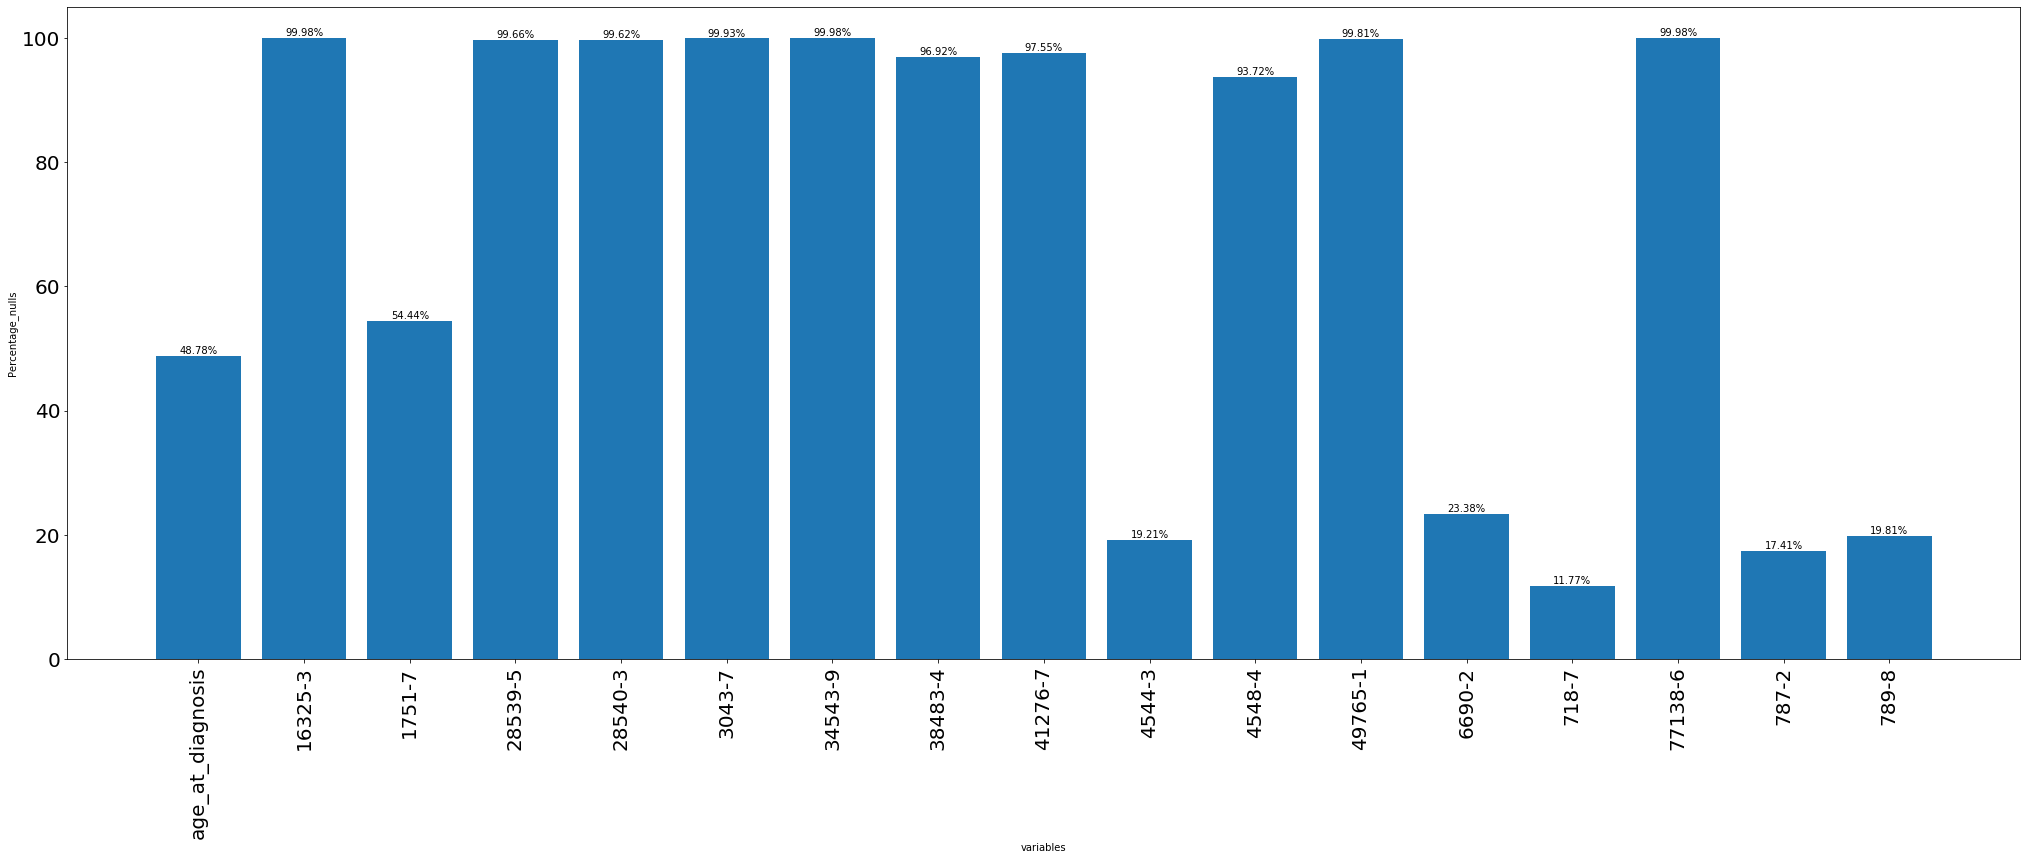

In [18]:
#21
#data exploration
#calculating total nulls
import matplotlib.pyplot as plt
#data exploration
# Calculating the total count of null values
null_count = df_pd.isnull().sum().sum()

# Calculating the total count of values in the DataFrame
total_count = df_pd.size

# Calculating the percentage of null values
percentage = (null_count / total_count) * 100

# Printing the overall null percentage
print("Overall null percentage:", percentage)

# Calculating and printing the null percentages for each column
col_list_nonulls=[]
col_list_percentages=[]
for column in df_pd.columns:
    null_col = df_pd[column].isnull().sum()
    total_values = len(df_pd[column])
    percentage_col = (null_col / total_values) * 100
    if percentage_col >0:
        col_list_nonulls.append(column)
        col_list_percentages.append(percentage_col)
        col_mean=df_pd[column].mean()
        #print("Column:", column, " Null percentage:", percentage_col, " nulls_count: ", null_col," total_count: ", total_values, "mean: ", col_mean)
    else:
        continue
        
col_list_percentages_round=np.round(col_list_percentages, decimals=2)
plt.figure(figsize=(35,12))
plt.bar(col_list_nonulls,col_list_percentages_round)

plt.xlabel('variables')
plt.ylabel('Percentage_nulls')
for category, percentage in zip(col_list_nonulls, col_list_percentages_round):
     plt.text(category, percentage, str(percentage) + '%', ha='center', va='bottom')
     plt.xticks(fontsize=20, rotation=90)  # Increase font size for x-axis tick labels and rotate them for better readability
     plt.yticks(fontsize=20)  # Increase font size for y-axis tick labels
plt.show()

In [19]:
#22
a=df_pd.isna().sum()
a.sort_values()

White                     0
EPI                       0
Female                    0
Male                      0
other_gender              0
Asian                     0
Black                     0
Other_race                0
Hispanic                  0
nD64_9                    0
nZ79_82                   0
nN39_0                    0
nI48_91                   0
nF32_9                    0
nZ87_891                  0
nF41_9                    0
nR05                      0
nI10                      0
nE11_9                    0
nE78_5                    0
nZ79_01                   0
nI25_10                   0
nZ23                      0
nE03_9                    0
nZ79_899                  0
nS09_90XA                 0
nF17_210                  0
nR10_9                    0
nK21_9                    0
718-7                149064
787-2                220517
4544-3               243252
789-8                250928
6690-2               296102
age_at_diagnosis     617780
1751-7              

In [23]:
#23
df_pd.columns

Index(['age_at_diagnosis', 'nR05', 'nI10', 'nE11_9', 'nE78_5', 'nZ23',
       'nI25_10', 'nK21_9', 'nE03_9', 'nZ79_899', 'nS09_90XA', 'nF17_210',
       'nR10_9', 'nF41_9', 'nZ79_01', 'nF32_9', 'nZ87_891', 'nI48_91',
       'nN39_0', 'nZ79_82', 'nD64_9', '16325-3', '1751-7', '28539-5',
       '28540-3', '3043-7', '34543-9', '38483-4', '41276-7', '4544-3',
       '4548-4', '49765-1', '6690-2', '718-7', '77138-6', '787-2', '789-8',
       'EPI', 'Female', 'Male', 'other_gender', 'Asian', 'Black', 'Hispanic',
       'Other_race', 'White'],
      dtype='object')

In [ ]:
spark_df = spark.createDataFrame(df_pd)

In [ ]:
spark_df.createOrReplaceTempView('df_pd_final')

In [ ]:
result = spark.sql("SELECT DISTINCT `718-7`, COUNT(*) AS count_of_records FROM df_pd_final GROUP BY `718-7`")

In [ ]:
result_cd = spark.sql("SELECT COUNT(DISTINCT `718-7`) AS count_of_records FROM df_pd_final")

In [ ]:
result_cd.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already executed the query and obtained the result as `result_4`
# Replace this line with the actual query execution
rg_1 = spark.sql("SELECT `718-7`, COUNT(*) AS count_of_records FROM df_pd_final GROUP BY `718-7`")

# Convert the Spark DataFrame to a Pandas DataFrame
result_df = rg_1.toPandas()

# Calculate the percentage of each count_of_records value
total_records = result_df['count_of_records'].sum()
result_df['percentage'] = (result_df['count_of_records'] / total_records) * 100

# Sort the DataFrame by '718-7' column
result_df = result_df.sort_values(by='718-7')

# Create the bar plot
plt.figure(figsize=(12, 6))  # Increase the figure size to provide more space
plt.bar(result_df['718-7'], result_df['percentage'], align='center', alpha=0.8)

# Add data labels on the bars with reduced font size
for category, percentage in zip(result_df['718-7'], result_df['percentage']):
    plt.text(category, percentage, f"{percentage:.2f}%", ha='center', va='bottom', fontsize=20)

# Set labels and title
plt.xlabel('variables', fontsize=20)
plt.ylabel('Percentage_means', fontsize=20)
plt.title('Bar Chart: 718-7 vs Percentage of Records', fontsize=24)

# Rotate the x-axis labels by 45 degrees and aligned them to the right for better readability
plt.xticks(rotation=45, ha='right', fontsize=20)

# Increase font size for y-axis tick labels
plt.yticks(fontsize=20)

# Show the plot
# plt.tight_layout()  # Ensure all elements fit in the plot area
plt.show()

In [ ]:
result_1 = spark.sql("SELECT `4544-3`, COUNT(*) AS count_of_records FROM df_pd_final GROUP BY `4544-3`")

In [ ]:
result_1.show()

In [ ]:
result_2 = spark.sql("SELECT `6690-2`, COUNT(*) AS count_of_records FROM df_pd_final GROUP BY `6690-2`")

In [ ]:
result_2.show()

In [ ]:
result_3 = spark.sql("SELECT `787-2`, COUNT(*) AS count_of_records FROM df_pd_final GROUP BY `787-2`")

In [ ]:
result_3.show()

In [ ]:
result_4 = spark.sql("SELECT `789-8`, COUNT(*) AS count_of_records FROM df_pd_final GROUP BY `789-8`")

In [ ]:
result_4.show()

In [ ]:
result1 = spark.sql("SELECT COUNT(`6690-2`) AS count_of_records FROM df_pd_final")

In [ ]:
result1.show()

In [24]:
#24
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


In [25]:
#25
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import *

def simpleXGBlearn(data, targetcolumn):
    feature = data.drop([targetcolumn], axis=1)
    cols = feature.columns
#     print(cols)
#     feature_num = feature
    
    feature[cols] = feature[cols].replace({pd.NA: np.nan})
    feature[cols] = feature[cols].apply(pd.to_numeric, errors='coerce')
#     feature['age']=feature['age'].astype('float16')
#     print(feature.info())
#     print(feature.info())
#     
#     imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    
#     feature_num[cols] = imputer.fit_transform(feature[cols])

    

    scaler = MinMaxScaler()
    feature[cols] = scaler.fit_transform(feature[cols])
#     feature_num
    target = data[targetcolumn]

    labelencoder = LabelEncoder()
    target_encoded = labelencoder.fit_transform(target)
#     target_encoded
    
    X_train, X_test, y_train, y_test = train_test_split(feature, target_encoded, test_size=0.3, random_state=42)
    #X_train = X_train.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
    model_xgb = XGBClassifier(n_jobs=-1, max_depth=15,subsample=1,n_estimators=100,learning_rate=0.02,min_child_weight=5)
    #model_xgb = XGBClassifier(n_jobs=-1)
#     model_xgb = GradientBoostingClassifier()
    model_xgb.fit(X_train,y_train) # use xgboost because it is good at handling nan
    predict = model_xgb.predict(X_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, predict).ravel()
    sensitivity = tp / (fn + tp)
    specificity = tn / (tn+fp)
    #accuarcy_train=accuracy_score(y_train, predict)
    #print(accuracy_train)
    print('sensitivity: ',sensitivity)
    print('specificity: ',specificity)
    
    print(classification_report(y_test, predict))
    print('roc_auc: ' , roc_auc_score(y_test, predict))
    return model_xgb


In [26]:
#26
#imputing the value for age using mean
import numpy as np
from sklearn.impute import SimpleImputer
preprocessor = SimpleImputer(missing_values=np.nan, strategy='mean')
X = np.array(df_pd['age_at_diagnosis']).reshape(-1,1)
preprocessor.fit(X)
X_prep = preprocessor.transform(X)
df_pd['age_at_diagnosis_transformed'] = X_prep.reshape(1,-1)[0]
#df_pd.head()
#df_pd=df_pd.drop("age_at_diagnosis",axis=1)
df_pd

,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,...,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White,age_at_diagnosis_transformed
0,NaN,8,60,28,9,3,0,5,38,55,...,1,1,0,0,0,0,0,1,0,43.896510
1,NaN,0,7,6,9,1,5,9,0,0,...,0,1,0,0,0,0,0,1,0,43.896510
2,NaN,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,43.896510
3,85.822581,0,0,0,8,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,85.822581
4,78.596214,0,11,6,5,0,3,0,0,2,...,1,0,1,0,0,0,0,1,0,78.596214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,NaN,0,3,2,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,43.896510
1266587,28.604344,0,0,0,0,0,0,0,0,5,...,0,0,1,0,0,0,0,1,0,28.604344
1266588,60.673930,0,11,0,0,0,0,0,13,10,...,0,1,0,0,0,0,0,0,1,60.673930
1266589,58.891295,4,38,0,2,1,0,2,28,12,...,0,1,0,0,0,0,0,0,1,58.891295


In [15]:
#27
column_to_drop_4 = 'age_at_diagnosis'
df_pd.drop(column_to_drop_4, axis=1, inplace=True)

In [16]:
#28
import numpy as np

In [17]:
#29
df_pd

,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,nS09_90XA,...,789-8,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White
0,8,60,28,9,3,0,5,38,55,1,...,NaN,1,1,0,0,0,0,0,1,0
1,0,7,6,9,1,5,9,0,0,1,...,4.90,0,1,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,4.43,0,0,1,0,0,0,0,1,0
3,0,0,0,8,0,0,0,0,0,3,...,3.69,0,1,0,0,0,0,0,0,1
4,0,11,6,5,0,3,0,0,2,0,...,5.64,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,0,3,2,0,0,1,0,0,0,2,...,4.71,0,0,1,0,0,0,0,1,0
1266587,0,0,0,0,0,0,0,0,5,1,...,4.57,0,0,1,0,0,0,0,1,0
1266588,0,11,0,0,0,0,0,13,10,0,...,4.67,0,1,0,0,0,0,0,0,1
1266589,4,38,0,2,1,0,2,28,12,0,...,4.36,0,1,0,0,0,0,0,0,1


In [30]:
#30
df_pd.isna().sum()

nR05                                  0
nI10                                  0
nE11_9                                0
nE78_5                                0
nZ23                                  0
nI25_10                               0
nK21_9                                0
nE03_9                                0
nZ79_899                              0
nS09_90XA                             0
nF17_210                              0
nR10_9                                0
nF41_9                                0
nZ79_01                               0
nF32_9                                0
nZ87_891                              0
nI48_91                               0
nN39_0                                0
nZ79_82                               0
nD64_9                                0
16325-3                         1266390
1751-7                           689536
28539-5                         1262335
28540-3                         1261820
3043-7                          1265733


In [31]:
#31
df_pd

,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,nS09_90XA,...,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White,age_at_diagnosis_transformed
0,8,60,28,9,3,0,5,38,55,1,...,1,1,0,0,0,0,0,1,0,43.896510
1,0,7,6,9,1,5,9,0,0,1,...,0,1,0,0,0,0,0,1,0,43.896510
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,43.896510
3,0,0,0,8,0,0,0,0,0,3,...,0,1,0,0,0,0,0,0,1,85.822581
4,0,11,6,5,0,3,0,0,2,0,...,1,0,1,0,0,0,0,1,0,78.596214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,0,3,2,0,0,1,0,0,0,2,...,0,0,1,0,0,0,0,1,0,43.896510
1266587,0,0,0,0,0,0,0,0,5,1,...,0,0,1,0,0,0,0,1,0,28.604344
1266588,0,11,0,0,0,0,0,13,10,0,...,0,1,0,0,0,0,0,0,1,60.673930
1266589,4,38,0,2,1,0,2,28,12,0,...,0,1,0,0,0,0,0,0,1,58.891295


In [32]:
#32
con1=df_pd.groupby(["EPI"])["EPI"].count()
con1

EPI
0    937095
1    329496
Name: EPI, dtype: int64

In [33]:
#33
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


In [34]:
%%time
model_xgb = simpleXGBlearn(df_pd,'EPI')
#34

sensitivity:  0.32449413193039256
specificity:  0.934982108430735
              precision    recall  f1-score   support

           0       0.80      0.93      0.86    281138
           1       0.64      0.32      0.43     98840

    accuracy                           0.78    379978
   macro avg       0.72      0.63      0.65    379978
weighted avg       0.76      0.78      0.75    379978

roc_auc:  0.6297381201805637
CPU times: user 24min 10s, sys: 7.28 s, total: 24min 17s
Wall time: 2min 1s


In [21]:
#35
from sklearn.utils import resample
#create two different dataframe of majority and minority class 

In [42]:
#36
df_minority = df_pd[(df_pd['EPI']==0)] 
df_majority = df_pd[(df_pd['EPI']==1)] 

# upsample minority class
df_minority_upsampled = resample(df_minority, 
                                 replace=True,    # sample with replacement
                                 random_state=42)  # reproducible results
# Combine majority class with upsampled minority class
df_pd_u = pd.concat([df_minority_upsampled, df_majority])

In [43]:
#37
df_pd.groupby(["EPI"]).count()

,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,nS09_90XA,...,789-8,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White,age_at_diagnosis_transformed
EPI,,,,,,,,,,,,,,,,,,,,,
0,937095,937095,937095,937095,937095,937095,937095,937095,937095,937095,...,744713,937095,937095,937095,937095,937095,937095,937095,937095,937095
1,329496,329496,329496,329496,329496,329496,329496,329496,329496,329496,...,270950,329496,329496,329496,329496,329496,329496,329496,329496,329496


In [44]:
#38
df_pd

,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,nS09_90XA,...,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White,age_at_diagnosis_transformed
0,8,60,28,9,3,0,5,38,55,1,...,1,1,0,0,0,0,0,1,0,43.896510
1,0,7,6,9,1,5,9,0,0,1,...,0,1,0,0,0,0,0,1,0,43.896510
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,43.896510
3,0,0,0,8,0,0,0,0,0,3,...,0,1,0,0,0,0,0,0,1,85.822581
4,0,11,6,5,0,3,0,0,2,0,...,1,0,1,0,0,0,0,1,0,78.596214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266586,0,3,2,0,0,1,0,0,0,2,...,0,0,1,0,0,0,0,1,0,43.896510
1266587,0,0,0,0,0,0,0,0,5,1,...,0,0,1,0,0,0,0,1,0,28.604344
1266588,0,11,0,0,0,0,0,13,10,0,...,0,1,0,0,0,0,0,0,1,60.673930
1266589,4,38,0,2,1,0,2,28,12,0,...,0,1,0,0,0,0,0,0,1,58.891295


In [45]:
%%time
model_xgb = simpleXGBlearn(df_pd_u,'EPI')
#39

sensitivity:  0.1958640674394099
specificity:  0.9874392717517544
              precision    recall  f1-score   support

           0       0.86      0.99      0.92    489064
           1       0.76      0.20      0.31     98696

    accuracy                           0.85    587760
   macro avg       0.81      0.59      0.62    587760
weighted avg       0.84      0.85      0.82    587760

roc_auc:  0.5916516695955821
CPU times: user 55min 28s, sys: 10.1 s, total: 55min 38s
Wall time: 4min 4s


In [46]:
#40
df_pd_u.columns

Index(['nR05', 'nI10', 'nE11_9', 'nE78_5', 'nZ23', 'nI25_10', 'nK21_9',
       'nE03_9', 'nZ79_899', 'nS09_90XA', 'nF17_210', 'nR10_9', 'nF41_9',
       'nZ79_01', 'nF32_9', 'nZ87_891', 'nI48_91', 'nN39_0', 'nZ79_82',
       'nD64_9', '16325-3', '1751-7', '28539-5', '28540-3', '3043-7',
       '34543-9', '38483-4', '41276-7', '4544-3', '4548-4', '49765-1',
       '6690-2', '718-7', '77138-6', '787-2', '789-8', 'EPI', 'Female', 'Male',
       'other_gender', 'Asian', 'Black', 'Hispanic', 'Other_race', 'White',
       'age_at_diagnosis_transformed'],
      dtype='object')

In [47]:
#41
#under sampling
df_minority = df_pd[(df_pd['EPI']==0)] 
df_majority = df_pd[(df_pd['EPI']==1)] 

# upsample minority class
df_majority_undersampling = resample(df_majority, 
                                 replace=True,    # sample with replacement
                                 n_samples= 1164605, # to match majority class
                                 random_state=42)  # reproducible results
# Combine majority class with upsampled minority class
df_pd_d = pd.concat([df_minority, df_majority_undersampling])

In [48]:
%%time
xgb_Epilepsy = simpleXGBlearn(df_pd_d,'EPI')
#42

sensitivity:  0.8380303260175704
specificity:  0.6360354657097232
              precision    recall  f1-score   support

           0       0.76      0.64      0.69    281173
           1       0.74      0.84      0.79    349337

    accuracy                           0.75    630510
   macro avg       0.75      0.74      0.74    630510
weighted avg       0.75      0.75      0.74    630510

roc_auc:  0.7370328958636468
CPU times: user 58min 23s, sys: 10.9 s, total: 58min 34s
Wall time: 4min 21s


In [20]:
#43
df_minority = df_pd[(df_pd['EPI']==0)] 
df_majority = df_pd[(df_pd['EPI']==1)] 

# upsample minority class
df_minority_upsampled = resample(df_minority, 
                                 replace=True,    # sample with replacement
                                 n_samples= 1629703, # to match majority class
                                 random_state=42)  # reproducible results
# Combine majority class with upsampled minority class
df_b = pd.concat([df_minority_upsampled, df_majority])

NameError: name 'resample' is not defined

In [22]:
#44
#under sampling
df_minority = df_pd[(df_pd['EPI']==0)] 
df_majority = df_pd[(df_pd['EPI']==1)] 

# upsample minority class
df_majority_undersampling = resample(df_majority, 
                                 replace=True,    # sample with replacement
                                 n_samples= 1164605, # to match minority class
                                 random_state=42)  # reproducible results
# Combine majority class with upsampled minority class
df_b = pd.concat([df_minority, df_majority_undersampling])

In [51]:
%%time
xgb_Epilepsy = simpleXGBlearn(df_b,'EPI')
#45

sensitivity:  0.8380303260175704
specificity:  0.6360354657097232
              precision    recall  f1-score   support

           0       0.76      0.64      0.69    281173
           1       0.74      0.84      0.79    349337

    accuracy                           0.75    630510
   macro avg       0.75      0.74      0.74    630510
weighted avg       0.75      0.75      0.74    630510

roc_auc:  0.7370328958636468
CPU times: user 1h 11min 48s, sys: 11.7 s, total: 1h 12min
Wall time: 5min 16s


In [52]:
#46
df = pd.DataFrame({'features':xgb_Epilepsy.get_booster().feature_names, 'importance':xgb_Epilepsy.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [53]:
#47
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

In [54]:
#48
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45 entries, 25 to 8
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   features    45 non-null     string 
 1   importance  45 non-null     Float32
dtypes: Float32(1), string(1)
memory usage: 945.0 bytes


                        features  importance
25                       34543-9         0.0
20                       16325-3         0.0
33                       77138-6         0.0
31                        6690-2     0.00757
5                        nI25_10    0.007622
16                       nI48_91    0.007848
18                       nZ79_82    0.007857
24                        3043-7    0.007875
29                        4548-4    0.007893
35                         789-8    0.007905
28                        4544-3    0.007925
36                        Female     0.00799
3                         nE78_5    0.008088
32                         718-7    0.008098
21                        1751-7    0.008313
34                         787-2    0.008521
43                         White     0.00877
0                           nR05    0.008816
26                       38483-4    0.009021
15                      nZ87_891    0.009114
37                          Male    0.010109
13        

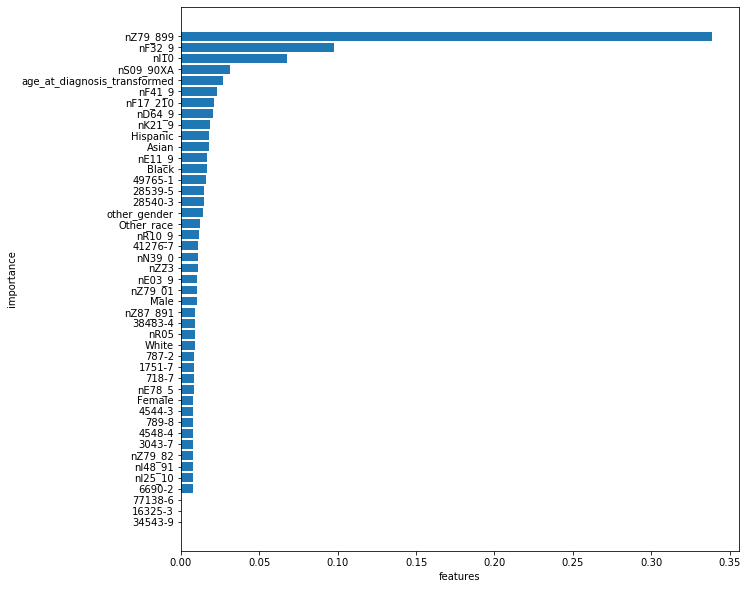

In [55]:
#49
xgbPlotFeatureImportance(xgb_Epilepsy)

In [56]:
#50
df_pd_ud=df_b.drop("nZ79_899", axis=1)

In [57]:
#51
df_pd_ud.columns

Index(['nR05', 'nI10', 'nE11_9', 'nE78_5', 'nZ23', 'nI25_10', 'nK21_9',
       'nE03_9', 'nS09_90XA', 'nF17_210', 'nR10_9', 'nF41_9', 'nZ79_01',
       'nF32_9', 'nZ87_891', 'nI48_91', 'nN39_0', 'nZ79_82', 'nD64_9',
       '16325-3', '1751-7', '28539-5', '28540-3', '3043-7', '34543-9',
       '38483-4', '41276-7', '4544-3', '4548-4', '49765-1', '6690-2', '718-7',
       '77138-6', '787-2', '789-8', 'EPI', 'Female', 'Male', 'other_gender',
       'Asian', 'Black', 'Hispanic', 'Other_race', 'White',
       'age_at_diagnosis_transformed'],
      dtype='object')

In [58]:
%%time
xgb_Epilepsy_r1 = simpleXGBlearn(df_pd_ud,'EPI')
#52

sensitivity:  0.8289302306941435
specificity:  0.6242135624686581
              precision    recall  f1-score   support

           0       0.75      0.62      0.68    281173
           1       0.73      0.83      0.78    349337

    accuracy                           0.74    630510
   macro avg       0.74      0.73      0.73    630510
weighted avg       0.74      0.74      0.73    630510

roc_auc:  0.7265718965814009
CPU times: user 1h 18min 52s, sys: 11.3 s, total: 1h 19min 3s
Wall time: 5min 44s


In [59]:
#53
df = pd.DataFrame({'features':xgb_Epilepsy_r1.get_booster().feature_names, 'importance':xgb_Epilepsy_r1.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [60]:
#54
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
32                       77138-6         0.0
24                       34543-9         0.0
19                       16325-3         0.0
5                        nI25_10    0.008194
30                        6690-2    0.008429
15                       nI48_91    0.008604
27                        4544-3    0.008643
31                         718-7    0.008939
28                        4548-4    0.008939
34                         789-8     0.00897
35                        Female    0.009187
23                        3043-7    0.009483
33                         787-2    0.009729
42                         White    0.009769
20                        1751-7    0.009898
3                         nE78_5    0.010221
0                           nR05    0.010263
25                       38483-4    0.010337
36                          Male    0.011489
41                    Other_race     0.01172
17                       nZ79_82    0.011818
26        

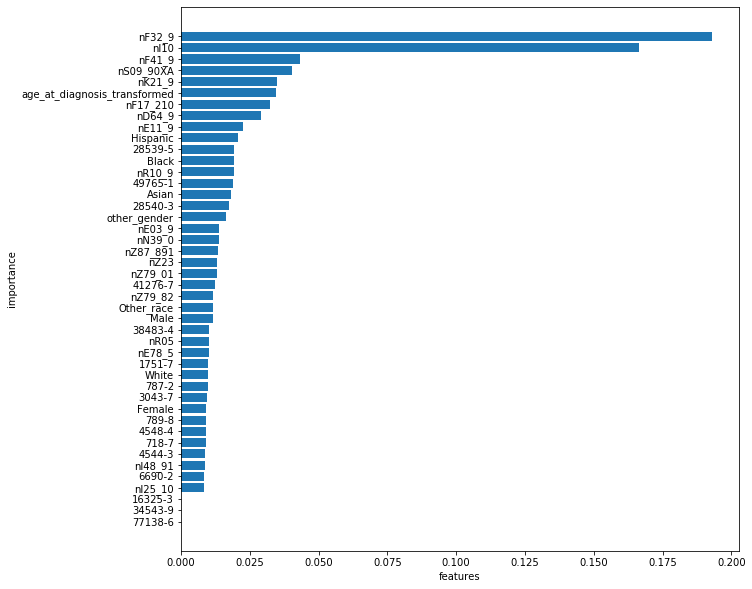

In [61]:
#55
xgbPlotFeatureImportance(xgb_Epilepsy_r1)

In [62]:
#56
df_pd_ud1=df_pd_ud.drop("nF32_9", axis=1)

In [63]:
#57
df_pd_ud1.columns

Index(['nR05', 'nI10', 'nE11_9', 'nE78_5', 'nZ23', 'nI25_10', 'nK21_9',
       'nE03_9', 'nS09_90XA', 'nF17_210', 'nR10_9', 'nF41_9', 'nZ79_01',
       'nZ87_891', 'nI48_91', 'nN39_0', 'nZ79_82', 'nD64_9', '16325-3',
       '1751-7', '28539-5', '28540-3', '3043-7', '34543-9', '38483-4',
       '41276-7', '4544-3', '4548-4', '49765-1', '6690-2', '718-7', '77138-6',
       '787-2', '789-8', 'EPI', 'Female', 'Male', 'other_gender', 'Asian',
       'Black', 'Hispanic', 'Other_race', 'White',
       'age_at_diagnosis_transformed'],
      dtype='object')

In [64]:
%%time
xgb_Epilepsy_r2 = simpleXGBlearn(df_pd_ud1,'EPI')
#58

sensitivity:  0.8296515971683504
specificity:  0.6182741586140916
              precision    recall  f1-score   support

           0       0.74      0.62      0.68    281173
           1       0.73      0.83      0.78    349337

    accuracy                           0.74    630510
   macro avg       0.74      0.72      0.73    630510
weighted avg       0.74      0.74      0.73    630510

roc_auc:  0.723962877891221
CPU times: user 1h 28min 13s, sys: 12.2 s, total: 1h 28min 25s
Wall time: 6min 26s


In [65]:
#59
df = pd.DataFrame({'features':xgb_Epilepsy_r2.get_booster().feature_names, 'importance':xgb_Epilepsy_r2.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [66]:
#60
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
23                       34543-9         0.0
18                       16325-3         0.0
31                       77138-6         0.0
5                        nI25_10    0.008537
29                        6690-2    0.008983
14                       nI48_91    0.009063
26                        4544-3    0.009366
34                        Female    0.009543
30                         718-7    0.009549
33                         789-8    0.009691
41                         White    0.009754
27                        4548-4    0.009772
32                         787-2    0.010418
19                        1751-7     0.01051
24                       38483-4    0.010612
0                           nR05    0.010947
3                         nE78_5    0.011838
16                       nZ79_82    0.012166
22                        3043-7    0.012553
40                    Other_race     0.01281
35                          Male    0.013013
25        

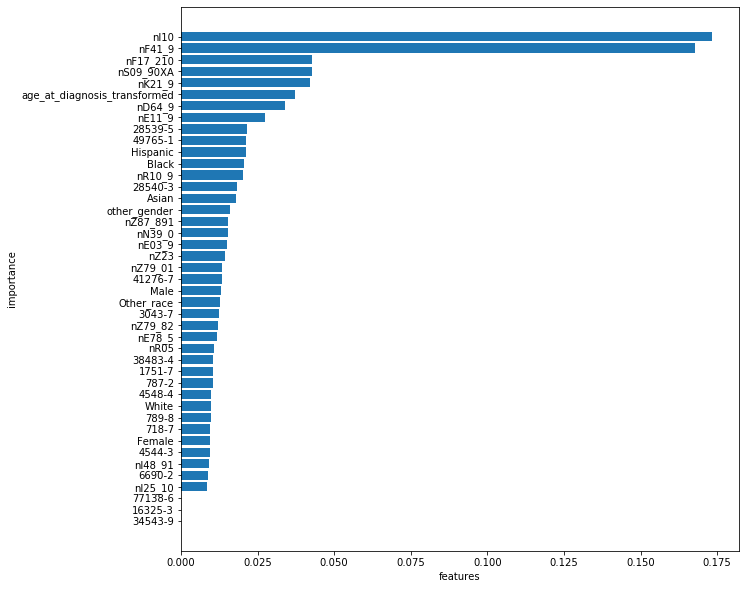

In [67]:
#61
xgbPlotFeatureImportance(xgb_Epilepsy_r2)

In [68]:
#62
df_pd_ud2=df_pd_ud1.drop("nI10", axis=1)

In [69]:
%%time
xgb_Epilepsy_r3 = simpleXGBlearn(df_pd_ud2,'EPI')
#63

sensitivity:  0.8267432307485322
specificity:  0.610485359547325
              precision    recall  f1-score   support

           0       0.74      0.61      0.67    281173
           1       0.73      0.83      0.77    349337

    accuracy                           0.73    630510
   macro avg       0.73      0.72      0.72    630510
weighted avg       0.73      0.73      0.73    630510

roc_auc:  0.7186142951479286
CPU times: user 1h 13min 8s, sys: 10.1 s, total: 1h 13min 18s
Wall time: 5min 20s


In [70]:
#64
df = pd.DataFrame({'features':xgb_Epilepsy_r3.get_booster().feature_names, 'importance':xgb_Epilepsy_r3.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [71]:
#65
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
22                       34543-9         0.0
30                       77138-6         0.0
17                       16325-3         0.0
28                        6690-2    0.008866
4                        nI25_10    0.009006
21                        3043-7    0.009234
13                       nI48_91    0.009264
25                        4544-3    0.009264
26                        4548-4    0.009451
40                         White    0.009482
29                         718-7    0.009514
32                         789-8    0.009584
33                        Female    0.009979
23                       38483-4    0.010177
0                           nR05    0.010435
31                         787-2    0.010439
18                        1751-7    0.010525
39                    Other_race    0.012652
15                       nZ79_82    0.013322
24                       41276-7    0.013349
34                          Male    0.014007
11        

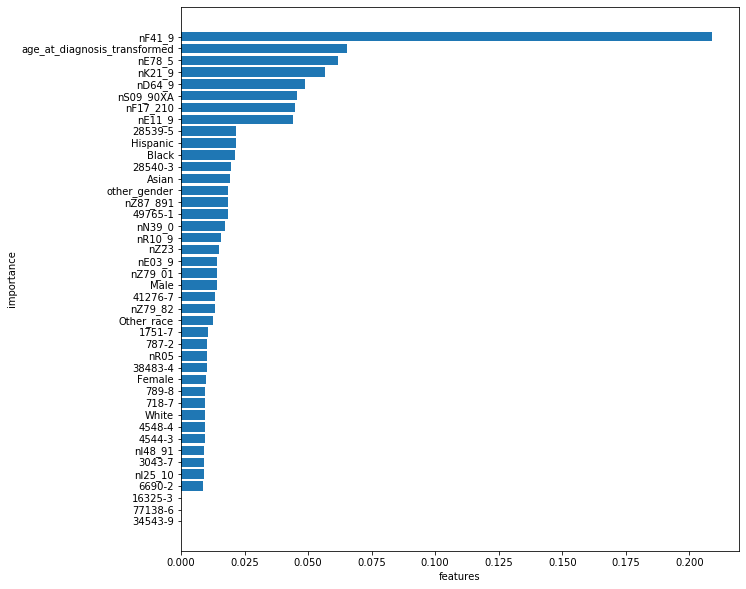

In [72]:
#66
xgbPlotFeatureImportance(xgb_Epilepsy_r3)

In [73]:
#67
df_pd_ud3=df_pd_ud2.drop("nF41_9", axis=1)

In [74]:
%%time
xgb_Epilepsy_r4 = simpleXGBlearn(df_pd_ud3,'EPI')
#68

sensitivity:  0.8220600737969354
specificity:  0.6007795912125276
              precision    recall  f1-score   support

           0       0.73      0.60      0.66    281173
           1       0.72      0.82      0.77    349337

    accuracy                           0.72    630510
   macro avg       0.72      0.71      0.71    630510
weighted avg       0.72      0.72      0.72    630510

roc_auc:  0.7114198325047314
CPU times: user 52min 22s, sys: 9.58 s, total: 52min 32s
Wall time: 3min 55s


In [75]:
#69
df = pd.DataFrame({'features':xgb_Epilepsy_r4.get_booster().feature_names, 'importance':xgb_Epilepsy_r4.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [76]:
#70
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
29                       77138-6         0.0
21                       34543-9         0.0
16                       16325-3         0.0
20                        3043-7    0.008318
4                        nI25_10    0.008906
27                        6690-2    0.009175
12                       nI48_91    0.009557
24                        4544-3     0.00969
25                        4548-4     0.00984
28                         718-7    0.009853
31                         789-8    0.009962
32                        Female    0.010089
0                           nR05    0.010209
39                         White    0.010588
22                       38483-4    0.010943
17                        1751-7    0.011064
30                         787-2    0.011074
23                       41276-7    0.013089
38                    Other_race    0.013236
14                       nZ79_82    0.014008
10                       nZ79_01    0.014347
19        

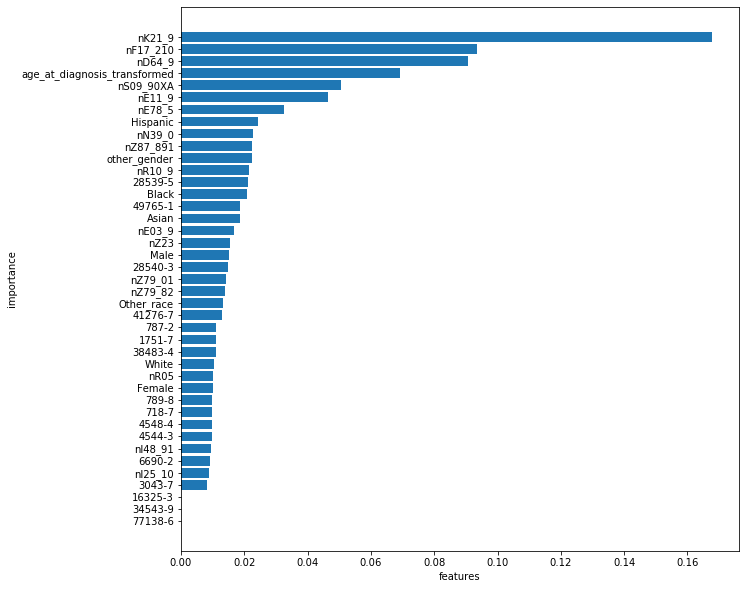

In [77]:
#71
xgbPlotFeatureImportance(xgb_Epilepsy_r4)

In [78]:
#72
df_pd_ud4=df_pd_ud3.drop("nK21_9", axis=1)

In [79]:
%%time
xgb_Epilepsy_r5 = simpleXGBlearn(df_pd_ud4,'EPI')
#73

sensitivity:  0.8202051314346891
specificity:  0.5943707254964026
              precision    recall  f1-score   support

           0       0.73      0.59      0.65    281173
           1       0.72      0.82      0.76    349337

    accuracy                           0.72    630510
   macro avg       0.72      0.71      0.71    630510
weighted avg       0.72      0.72      0.72    630510

roc_auc:  0.7072879284655458
CPU times: user 58min 36s, sys: 9.14 s, total: 58min 46s
Wall time: 4min 22s


In [80]:
#74
df = pd.DataFrame({'features':xgb_Epilepsy_r5.get_booster().feature_names, 'importance':xgb_Epilepsy_r5.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [81]:
#75
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
28                       77138-6         0.0
20                       34543-9         0.0
15                       16325-3         0.0
19                        3043-7    0.007575
26                        6690-2    0.009554
4                        nI25_10    0.009696
23                        4544-3     0.00986
24                        4548-4    0.010119
11                       nI48_91    0.010183
31                        Female     0.01038
30                         789-8    0.010466
38                         White    0.010603
27                         718-7    0.010691
29                         787-2    0.011529
16                        1751-7    0.011536
0                           nR05    0.011542
21                       38483-4    0.011814
37                    Other_race    0.013454
22                       41276-7    0.013677
3                           nZ23    0.015292
9                        nZ79_01    0.015774
13        

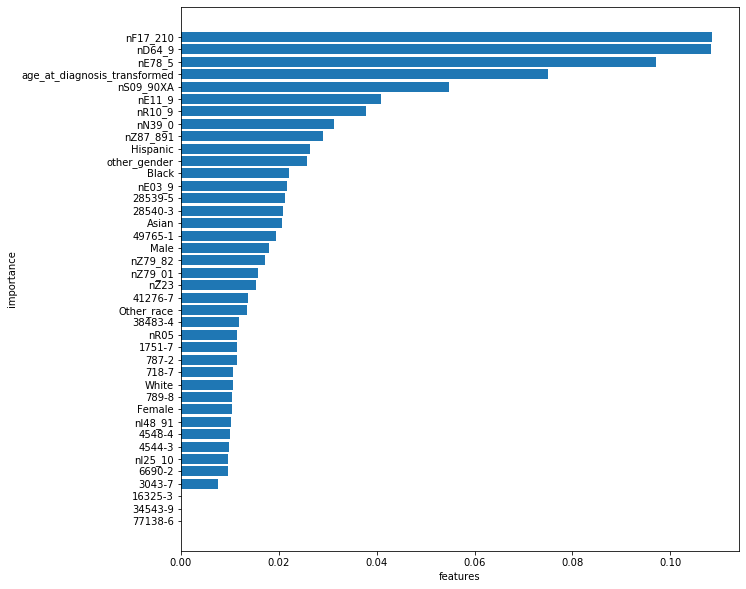

In [82]:
#76
xgbPlotFeatureImportance(xgb_Epilepsy_r5)

In [83]:
#77
df_pd_ud5=df_pd_ud4.drop("nF17_210", axis=1)

In [84]:
%%time
xgb_Epilepsy_r6 = simpleXGBlearn(df_pd_ud5,'EPI')
#78

sensitivity:  0.8192633474266968
specificity:  0.5883850867615311
              precision    recall  f1-score   support

           0       0.72      0.59      0.65    281173
           1       0.71      0.82      0.76    349337

    accuracy                           0.72    630510
   macro avg       0.72      0.70      0.71    630510
weighted avg       0.72      0.72      0.71    630510

roc_auc:  0.703824217094114
CPU times: user 52min 45s, sys: 9.05 s, total: 52min 54s
Wall time: 3min 57s


In [85]:
#79
df = pd.DataFrame({'features':xgb_Epilepsy_r6.get_booster().feature_names, 'importance':xgb_Epilepsy_r6.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [86]:
#80
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

In [87]:
#81
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 39 entries, 19 to 13
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   features    39 non-null     string 
 1   importance  39 non-null     Float32
dtypes: Float32(1), string(1)
memory usage: 819.0 bytes


                        features  importance
19                       34543-9         0.0
27                       77138-6         0.0
14                       16325-3         0.0
18                        3043-7    0.009025
30                        Female    0.010758
25                        6690-2    0.010794
4                        nI25_10    0.011194
22                        4544-3     0.01131
10                       nI48_91     0.01135
23                        4548-4    0.011379
29                         789-8    0.011839
26                         718-7    0.012686
37                         White    0.012996
15                        1751-7    0.013194
0                           nR05    0.013393
20                       38483-4    0.013552
28                         787-2    0.014307
36                    Other_race     0.01437
21                       41276-7    0.015081
8                        nZ79_01    0.017078
3                           nZ23    0.017486
31        

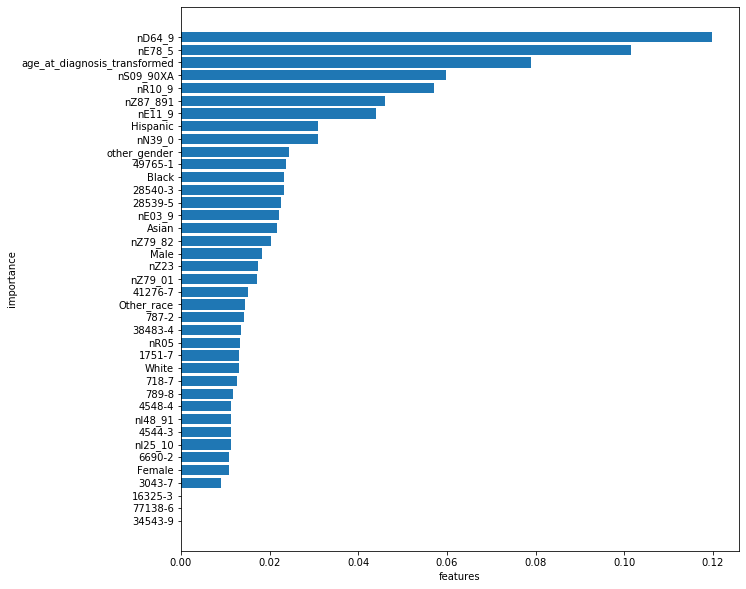

In [88]:
#82
xgbPlotFeatureImportance(xgb_Epilepsy_r6)

In [89]:
#83
df_pd_ud6=df_pd_ud5.drop("nD64_9", axis=1)

In [90]:
%%time
xgb_Epilepsy_r7 = simpleXGBlearn(df_pd_ud6,'EPI')
#84

sensitivity:  0.8198358605014642
specificity:  0.5810728626148315
              precision    recall  f1-score   support

           0       0.72      0.58      0.64    281173
           1       0.71      0.82      0.76    349337

    accuracy                           0.71    630510
   macro avg       0.72      0.70      0.70    630510
weighted avg       0.71      0.71      0.71    630510

roc_auc:  0.7004543615581478
CPU times: user 1h 23min 35s, sys: 12.2 s, total: 1h 23min 47s
Wall time: 6min 9s


In [91]:
#86
df = pd.DataFrame({'features':xgb_Epilepsy_r7.get_booster().feature_names, 'importance':xgb_Epilepsy_r7.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [92]:
#87
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
18                       34543-9         0.0
26                       77138-6         0.0
13                       16325-3         0.0
17                        3043-7     0.01041
29                        Female    0.011264
24                        6690-2    0.011376
21                        4544-3    0.011895
22                        4548-4    0.011905
10                       nI48_91    0.012187
4                        nI25_10    0.012219
25                         718-7    0.012423
28                         789-8    0.012618
36                         White    0.013327
14                        1751-7    0.013812
0                           nR05    0.013963
19                       38483-4    0.014394
27                         787-2    0.014928
20                       41276-7    0.016206
35                    Other_race    0.016277
3                           nZ23    0.018064
16                       28540-3    0.020487
8         

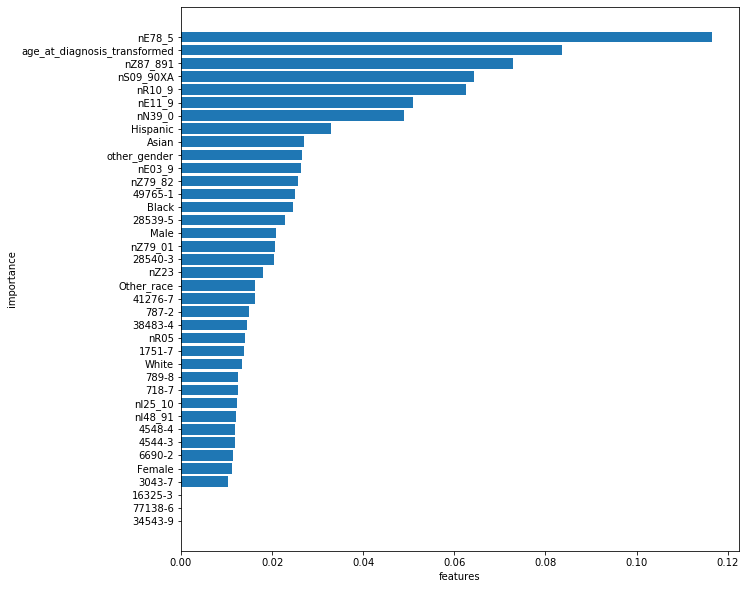

In [93]:
#88
xgbPlotFeatureImportance(xgb_Epilepsy_r7)

In [94]:
#89
df_pd_ud7=df_pd_ud6.drop("nE78_5", axis=1)

In [95]:
%%time
xgb_Epilepsy_r8 = simpleXGBlearn(df_pd_ud7,'EPI')
#90

sensitivity:  0.8156164391404289
specificity:  0.5797640598492743
              precision    recall  f1-score   support

           0       0.72      0.58      0.64    281173
           1       0.71      0.82      0.76    349337

    accuracy                           0.71    630510
   macro avg       0.71      0.70      0.70    630510
weighted avg       0.71      0.71      0.71    630510

roc_auc:  0.6976902494948516
CPU times: user 51min 56s, sys: 8.61 s, total: 52min 4s
Wall time: 3min 54s


In [96]:
#91
df = pd.DataFrame({'features':xgb_Epilepsy_r8.get_booster().feature_names, 'importance':xgb_Epilepsy_r8.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [97]:
#92
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
25                       77138-6         0.0
17                       34543-9         0.0
12                       16325-3         0.0
23                        6690-2    0.011254
16                        3043-7    0.011319
28                        Female    0.011582
20                        4544-3    0.011744
9                        nI48_91    0.012202
21                        4548-4    0.012234
27                         789-8    0.012519
24                         718-7    0.012787
0                           nR05    0.013685
18                       38483-4    0.013924
3                        nI25_10    0.013983
13                        1751-7    0.014043
35                         White    0.014155
26                         787-2    0.015001
34                    Other_race    0.016143
19                       41276-7    0.016587
2                           nZ23    0.018405
15                       28540-3    0.020181
29        

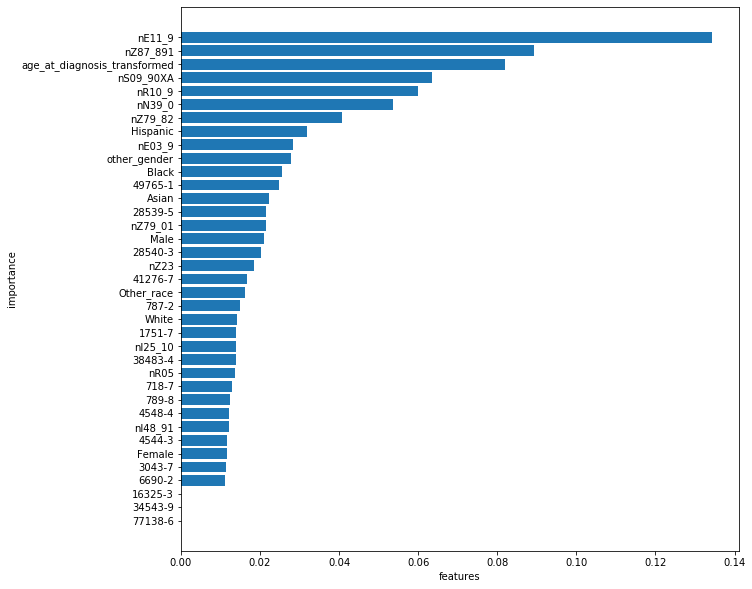

In [98]:
#93
xgbPlotFeatureImportance(xgb_Epilepsy_r8)

In [99]:
#93
df_pd_ud8=df_pd_ud7.drop("nE11_9", axis=1)

In [100]:
%%time
xgb_Epilepsy_r9 = simpleXGBlearn(df_pd_ud8,'EPI')
#94

sensitivity:  0.8154962113947277
specificity:  0.571598268681559
              precision    recall  f1-score   support

           0       0.71      0.57      0.63    281173
           1       0.70      0.82      0.75    349337

    accuracy                           0.71    630510
   macro avg       0.71      0.69      0.69    630510
weighted avg       0.71      0.71      0.70    630510

roc_auc:  0.6935472400381434
CPU times: user 51min 34s, sys: 8.62 s, total: 51min 43s
Wall time: 3min 49s


In [101]:
#95
df = pd.DataFrame({'features':xgb_Epilepsy_r9.get_booster().feature_names, 'importance':xgb_Epilepsy_r9.feature_importances_}).convert_dtypes()
df = df.sort_values(by='importance')

In [102]:
#96
def xgbPlotFeatureImportance(model_xgb):
    df = pd.DataFrame({'features':model_xgb.get_booster().feature_names, 'importance':model_xgb.feature_importances_}).convert_dtypes()
    df = df.sort_values(by='importance')
    print(df)
    plt.figure(figsize=(10,10))
    plt.barh(df.features, df.importance)
    plt.xlabel('features')
    plt.ylabel('importance')

                        features  importance
24                       77138-6         0.0
16                       34543-9         0.0
11                       16325-3         0.0
22                        6690-2    0.011449
15                        3043-7    0.011573
19                        4544-3     0.01212
27                        Female    0.012256
26                         789-8    0.012502
8                        nI48_91    0.012679
23                         718-7    0.013152
17                       38483-4    0.013815
20                        4548-4    0.014299
0                           nR05    0.014332
12                        1751-7    0.014752
34                         White    0.014976
25                         787-2    0.015038
18                       41276-7    0.016454
33                    Other_race      0.0179
1                           nZ23    0.018592
13                       28539-5    0.019782
30                         Asian    0.020875
2         

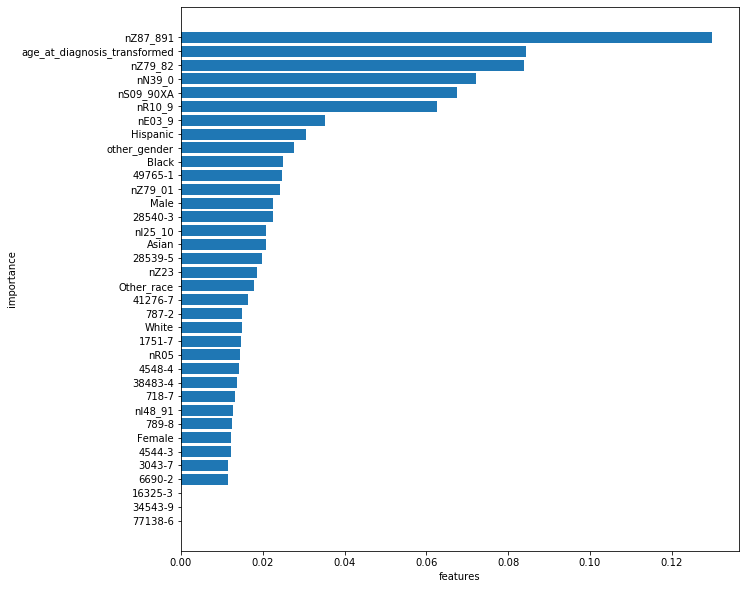

In [103]:
#97
xgbPlotFeatureImportance(xgb_Epilepsy_r9)

In [104]:
#98
df_pd_ud9=df_pd_ud8.drop("nZ87_891", axis=1)

In [105]:
%%time
xgb_Epilepsy_r10 = simpleXGBlearn(df_pd_ud9,'EPI')
#99

sensitivity:  0.812616470628648
specificity:  0.5681022004246495
              precision    recall  f1-score   support

           0       0.71      0.57      0.63    281173
           1       0.70      0.81      0.75    349337

    accuracy                           0.70    630510
   macro avg       0.70      0.69      0.69    630510
weighted avg       0.70      0.70      0.70    630510

roc_auc:  0.6903593355266487
CPU times: user 51min 23s, sys: 8.2 s, total: 51min 32s
Wall time: 3min 49s


In [ ]:
plt.figure(figsize=(10,10))
plt.barh(df.features, df.importance)
plt.xlabel('features')
plt.ylabel('importance')

In [ ]:
plt.barh(df['features'], df['importance'])

# Random Forest

In [23]:
from sklearn.utils import resample

In [24]:
df_minority = df_pd[(df_pd['EPI']==0)] 
df_majority = df_pd[(df_pd['EPI']==1)] 

# upsample minority class
df_minority_upsampled = resample(df_minority, 
                                 replace=True,    # sample with replacement
                                 n_samples= 1629703, # to match majority class
                                 random_state=42)  # reproducible results
# Combine majority class with upsampled minority class
df_b = pd.concat([df_minority_upsampled, df_majority])

In [25]:
#under sampling
df_minority = df_pd[(df_pd['EPI']==0)] 
df_majority = df_pd[(df_pd['EPI']==1)] 

# upsample minority class
df_majority_undersampling = resample(df_majority, 
                                 replace=True,    # sample with replacement
                                 n_samples= 1164605, # to match minority class
                                 random_state=42)  # reproducible results
# Combine majority class with upsampled minority class
df_b = pd.concat([df_minority, df_majority_undersampling])

In [26]:
df_b

,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,...,789-8,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White
1,NaN,0,7,6,9,1,5,9,0,0,...,4.90,0,1,0,0,0,0,0,1,0
2,NaN,0,0,0,0,0,0,0,0,0,...,4.43,0,0,1,0,0,0,0,1,0
3,85.822581,0,0,0,8,0,0,0,0,0,...,3.69,0,1,0,0,0,0,0,0,1
5,NaN,0,0,0,0,10,0,0,0,0,...,4.66,0,1,0,0,0,0,0,1,0
7,63.685017,2,0,0,0,0,0,0,0,0,...,4.68,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949878,NaN,0,6,0,0,0,0,0,0,0,...,4.23,1,0,1,0,0,0,0,1,0
1127567,NaN,0,42,0,24,10,0,0,0,0,...,4.44,1,1,0,0,0,0,0,1,0
956087,NaN,0,28,0,3,1,0,0,0,4,...,NaN,1,0,1,0,0,0,0,0,1
150472,NaN,25,2,4,0,0,0,0,0,2,...,4.91,1,0,1,0,0,0,0,1,0


In [27]:
df_b.columns

Index(['age_at_diagnosis', 'nR05', 'nI10', 'nE11_9', 'nE78_5', 'nZ23',
       'nI25_10', 'nK21_9', 'nE03_9', 'nZ79_899', 'nS09_90XA', 'nF17_210',
       'nR10_9', 'nF41_9', 'nZ79_01', 'nF32_9', 'nZ87_891', 'nI48_91',
       'nN39_0', 'nZ79_82', 'nD64_9', '16325-3', '1751-7', '28539-5',
       '28540-3', '3043-7', '34543-9', '38483-4', '41276-7', '4544-3',
       '4548-4', '49765-1', '6690-2', '718-7', '77138-6', '787-2', '789-8',
       'EPI', 'Female', 'Male', 'other_gender', 'Asian', 'Black', 'Hispanic',
       'Other_race', 'White'],
      dtype='object')

In [28]:
# First, calculate the mean for the columns
mean_column1 = df_b['4544-3'].median()
mean_column2 = df_b['6690-2'].median()
mean_column3 = df_b['718-7'].median()
mean_column4 = df_b['787-2'].median()
mean_column5 = df_b['789-8'].median()
# mean_column6 = df_u['age_at_diagnosis'].mean()
# Then, use fillna() to replace the missing values with the median or mean for each column
df_pd_imputed = df_b.copy()
df_pd_imputed['4544-3'].fillna(mean_column1, inplace=True)
df_pd_imputed['6690-2'].fillna(mean_column2, inplace=True)
df_pd_imputed['718-7'].fillna(mean_column3, inplace=True)
df_pd_imputed['787-2'].fillna(mean_column4, inplace=True)
df_pd_imputed['789-8'].fillna(mean_column5, inplace=True)
# df_pd_imputed['age_at_diagnosis'].fillna(mean_column6, inplace=True)

In [29]:
df_pd_imputed

,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,...,789-8,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White
1,NaN,0,7,6,9,1,5,9,0,0,...,4.90,0,1,0,0,0,0,0,1,0
2,NaN,0,0,0,0,0,0,0,0,0,...,4.43,0,0,1,0,0,0,0,1,0
3,85.822581,0,0,0,8,0,0,0,0,0,...,3.69,0,1,0,0,0,0,0,0,1
5,NaN,0,0,0,0,10,0,0,0,0,...,4.66,0,1,0,0,0,0,0,1,0
7,63.685017,2,0,0,0,0,0,0,0,0,...,4.68,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949878,NaN,0,6,0,0,0,0,0,0,0,...,4.23,1,0,1,0,0,0,0,1,0
1127567,NaN,0,42,0,24,10,0,0,0,0,...,4.44,1,1,0,0,0,0,0,1,0
956087,NaN,0,28,0,3,1,0,0,0,4,...,4.53,1,0,1,0,0,0,0,0,1
150472,NaN,25,2,4,0,0,0,0,0,2,...,4.91,1,0,1,0,0,0,0,1,0


In [30]:
df_pd_nomissing= df_pd_imputed.fillna(0)

In [31]:
df_pd_nomissing

,age_at_diagnosis,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nZ79_899,...,789-8,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White
1,0.000000,0,7,6,9,1,5,9,0,0,...,4.90,0,1,0,0,0,0,0,1,0
2,0.000000,0,0,0,0,0,0,0,0,0,...,4.43,0,0,1,0,0,0,0,1,0
3,85.822581,0,0,0,8,0,0,0,0,0,...,3.69,0,1,0,0,0,0,0,0,1
5,0.000000,0,0,0,0,10,0,0,0,0,...,4.66,0,1,0,0,0,0,0,1,0
7,63.685017,2,0,0,0,0,0,0,0,0,...,4.68,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949878,0.000000,0,6,0,0,0,0,0,0,0,...,4.23,1,0,1,0,0,0,0,1,0
1127567,0.000000,0,42,0,24,10,0,0,0,0,...,4.44,1,1,0,0,0,0,0,1,0
956087,0.000000,0,28,0,3,1,0,0,0,4,...,4.53,1,0,1,0,0,0,0,0,1
150472,0.000000,25,2,4,0,0,0,0,0,2,...,4.91,1,0,1,0,0,0,0,1,0


In [47]:
df_pd.isna().sum()

personid                              0
age_at_diagnosis                 617780
nR05                                  0
nI10                                  0
nE11_9                                0
nE78_5                                0
nZ23                                  0
nI25_10                               0
nK21_9                                0
nE03_9                                0
nS09_90XA                             0
nF17_210                              0
nR10_9                                0
nF41_9                                0
nZ79_01                               0
nF32_9                                0
nZ87_891                              0
nI48_91                               0
nN39_0                                0
nZ79_82                               0
nD64_9                                0
16325-3                         1266390
1751-7                           689536
28539-5                         1262335
28540-3                         1261820


In [107]:
df_pd_nomissing

,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nS09_90XA,nF17_210,...,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White,age_at_diagnosis_transformed
1,0,7,6,9,1,5,9,0,1,0,...,0,1,0,0,0,0,0,1,0,43.896510
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,43.896510
3,0,0,0,8,0,0,0,0,3,0,...,0,1,0,0,0,0,0,0,1,85.822581
5,0,0,0,0,10,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,43.896510
7,2,0,0,0,0,0,0,0,2,2,...,0,1,0,0,0,0,0,0,1,63.685017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949878,0,6,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,43.896510
1127567,0,42,0,24,10,0,0,0,2,0,...,1,1,0,0,0,0,0,1,0,43.896510
956087,0,28,0,3,1,0,0,0,2,0,...,1,0,1,0,0,0,0,0,1,43.896510
150472,25,2,4,0,0,0,0,0,3,13,...,1,0,1,0,0,0,0,1,0,43.896510


In [27]:
df_pd_nomissing=df_pd_nomissing.drop("age_at_diagnosis", axis=1)

KeyError: "['age_at_diagnosis'] not found in axis"

In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

def RF(data, targetcolumn):
    feature = data.drop([targetcolumn], axis=1)
    cols = feature.columns
#     print(cols)
#     feature_num = feature
    
#    feature[cols] = feature[cols].replace({pd.NA: np.nan})
#    feature[cols] = feature[cols].apply(pd.to_numeric, errors='coerce')
#     feature['age']=feature['age'].astype('float16')
#     print(feature.info())
#     print(feature.info())
#     
#     imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    
#     feature_num[cols] = imputer.fit_transform(feature[cols])

    

    ##scaler = MinMaxScaler()
    ##feature[cols] = scaler.fit_transform(feature[cols])
#     feature_num
    target = data[targetcolumn]

    ##labelencoder = LabelEncoder()
    ##target_encoded = labelencoder.fit_transform(target)
#     target_encoded
    
    X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.3, random_state=42)
    #X_train = X_train.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
    #model_xgb = XGBClassifier(n_jobs=-1, max_depth=10,subsample=1,n_estimators=100,learning_rate=0.02,min_child_weight=5)
    
    #rf=RandomForestClassifier(n_estimators=200, max_depth=15)
    rf=RandomForestClassifier()
    #model_xgb = XGBClassifier(n_jobs=-1)
#     model_xgb = GradientBoostingClassifier()
    rf.fit(X_train,y_train) # use xgboost because it is good at handling nan
    predict = rf.predict(X_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, predict).ravel()
    sensitivity = tp / (fn + tp)
    specificity = tn / (tn+fp)
    #accuarcy_train=accuracy_score(y_train, predict)
    #print(accuracy_train)
    print('sensitivity: ',sensitivity)
    print('specificity: ',specificity)
    
    print(classification_report(y_test, predict))
    print('roc_auc: ' , roc_auc_score(y_test, predict))
    return rf

In [109]:
%%time
rf = RF(df_pd_nomissing,'EPI')

sensitivity:  0.9612380022728769
specificity:  0.8373954824965413
              precision    recall  f1-score   support

           0       0.95      0.84      0.89    281173
           1       0.88      0.96      0.92    349337

    accuracy                           0.91    630510
   macro avg       0.91      0.90      0.90    630510
weighted avg       0.91      0.91      0.91    630510

roc_auc:  0.899316742384709
CPU times: user 6min 44s, sys: 1.18 s, total: 6min 45s
Wall time: 6min 45s


# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import *

def naive_bayes(df, target):
    # Load the Iris dataset
    feature = df.drop([target], axis =1)
    target_var = df[target]

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(feature, target_var, test_size=0.3, random_state=42)

    # Create a Naive Bayes classifier
    nb_classifier = GaussianNB()

    # Train the classifier
    nb_classifier.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = nb_classifier.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (fn + tp)
    specificity = tn / (tn+fp)
    
    print('sensitivity: ',sensitivity)
    print('specificity: ',specificity)

    print(classification_report(y_test, y_pred))
    print('roc_auc: ' , roc_auc_score(y_test, y_pred))
    return nb_classifier


In [ ]:
%%time
nb_Epilepsy = naive_bayes(df_pd_nomissing,'EPI')

# MLP

In [ ]:
!pip install torch

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
df_pd= df_pd_nomissing
feature = df_pd.drop(['EPI'], axis=1)
cols = feature.columns

#feature[cols] = feature[cols].replace({pd.NA: np.nan})
#feature[cols] = feature[cols].apply(pd.to_numeric, errors='coerce')

scaler = MinMaxScaler()
feature[cols] = scaler.fit_transform(feature[cols])

target = df_pd['EPI']

labelencoder = LabelEncoder()
target_encoded = labelencoder.fit_transform(target)

X_train, X_test, y_train, y_test = train_test_split(feature, target_encoded, test_size=0.3, random_state=42)

#print(X_train, X_test)

In [ ]:
a = df_pd.to_numpy()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, roc_auc_score

# torch.set_num_threads(-1)

X_train_t = torch.tensor(X_train.to_numpy(), dtype=torch.float32) # coverting x_train to numpy array and then to torch tensor 
X_test_t = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        out = self.sigmoid(out)
        return out

# Set the hyperparameters
input_size = X_train_t.shape[1]
hidden_size = 128
output_size = 1
learning_rate = 0.01
num_epochs = 200

# Initialize the model, loss function, and optimizer
model = MLP(input_size, hidden_size, output_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
with torch.no_grad():
    predicted = model(X_test_t)
    predicted = torch.round(predicted)

    # Calculate accuracy
    correct = (predicted == y_test_t).sum().item()
    total = y_test_t.size(0)
    accuracy = correct / total
    print(f'Accuracy on test set: {accuracy:.4f}')

    # Calculate true negatives, false positives, false negatives, true positives
    true_negatives = ((predicted == 0) & (y_test_t == 0)).sum().item()
    false_positives = ((predicted == 1) & (y_test_t == 0)).sum().item()
    false_negatives = ((predicted == 0) & (y_test_t == 1)).sum().item()
    true_positives = ((predicted == 1) & (y_test_t == 1)).sum().item()

    # Calculate specificity and sensitivity
    specificity = true_negatives / (true_negatives + false_positives)
    sensitivity = true_positives / (true_positives + false_negatives)

    print(f'Specificity on test set: {specificity:.4f}')
    print(f'Sensitivity on test set: {sensitivity:.4f}')
    
   

    # Convert predicted tensor to numpy array
    predicted_np = predicted.numpy().flatten()

    # Convert y_test_t tensor to numpy array
    y_test_np = y_test_t.numpy().flatten()

    # Print the classification report
    print(classification_report(y_test_np, predicted_np))

    # Print the ROC AUC score
    print('roc_auc:', roc_auc_score(y_test_np, predicted_np))


In [110]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

def simpleDTlearn(data, targetcolumn):
    feature = data.drop([targetcolumn], axis=1)
    cols = feature.columns

    feature[cols] = feature[cols].replace({pd.NA: np.nan})
    feature[cols] = feature[cols].apply(pd.to_numeric, errors='coerce')

    scaler = MinMaxScaler()
    feature[cols] = scaler.fit_transform(feature[cols])

    target = data[targetcolumn]

    labelencoder = LabelEncoder()
    target_encoded = labelencoder.fit_transform(target)

    X_train, X_test, y_train, y_test = train_test_split(feature, target_encoded, test_size=0.3, random_state=42)

    model_dt = DecisionTreeClassifier(max_depth=15, min_samples_split=5)
    model_dt.fit(X_train, y_train)
    predict = model_dt.predict(X_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, predict).ravel()
    sensitivity = tp / (fn + tp)
    specificity = tn / (tn + fp)

    print('sensitivity: ', sensitivity)
    print('specificity: ', specificity)
    
    print(classification_report(y_test, predict))
    print('roc_auc: ', roc_auc_score(y_test, predict))
    return model_dt


In [111]:
df_pd_nomissing

,nR05,nI10,nE11_9,nE78_5,nZ23,nI25_10,nK21_9,nE03_9,nS09_90XA,nF17_210,...,EPI,Female,Male,other_gender,Asian,Black,Hispanic,Other_race,White,age_at_diagnosis_transformed
1,0,7,6,9,1,5,9,0,1,0,...,0,1,0,0,0,0,0,1,0,43.896510
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,43.896510
3,0,0,0,8,0,0,0,0,3,0,...,0,1,0,0,0,0,0,0,1,85.822581
5,0,0,0,0,10,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,43.896510
7,2,0,0,0,0,0,0,0,2,2,...,0,1,0,0,0,0,0,0,1,63.685017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949878,0,6,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,43.896510
1127567,0,42,0,24,10,0,0,0,2,0,...,1,1,0,0,0,0,0,1,0,43.896510
956087,0,28,0,3,1,0,0,0,2,0,...,1,0,1,0,0,0,0,0,1,43.896510
150472,25,2,4,0,0,0,0,0,3,13,...,1,0,1,0,0,0,0,1,0,43.896510


In [112]:
%%time
model_xgb = simpleDTlearn(df_pd_nomissing,'EPI')

sensitivity:  0.802219633190873
specificity:  0.6066478644820092
              precision    recall  f1-score   support

           0       0.71      0.61      0.65    281173
           1       0.72      0.80      0.76    349337

    accuracy                           0.72    630510
   macro avg       0.71      0.70      0.71    630510
weighted avg       0.71      0.72      0.71    630510

roc_auc:  0.704433748836441
CPU times: user 35 s, sys: 924 ms, total: 35.9 s
Wall time: 35.9 s


In [ ]:
import numpy as np
import pandas as pd
# from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def simple_stacking_learn(data, targetcolumn):
    X = data.drop([targetcolumn], axis=1)
    y = data[targetcolumn]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Create the base classifiers
    random_forest = RandomForestClassifier(random_state=42)
    decision_tree = DecisionTreeClassifier(random_state=42)
#     xgboost = XGBClassifier(random_state=42)

    # Create the stacking classifier with the base classifiers and a meta-classifier (LogisticRegression in this example)
#     estimators = [('rf', random_forest), ('dt', decision_tree), ('xgb', xgboost)]
    estimators = [('rf', random_forest), ('dt', decision_tree)]
    stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

    # Train the stacking classifier on the training data
    stacking_classifier.fit(X_train, y_train)

    # Make predictions on the testing data
    y_pred = stacking_classifier.predict(X_test)

    # Evaluate the accuracy of the stacking classifier
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy of the stacking classifier:", accuracy)

    return stacking_classifier

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def simple_stacking_learn(data, targetcolumn):
    X = data.drop([targetcolumn], axis=1)
    y = data[targetcolumn]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Create the base classifiers
    random_forest = RandomForestClassifier(random_state=42)
    decision_tree = DecisionTreeClassifier(random_state=42)
#     xgboost = XGBClassifier(random_state=42)

    # Create the stacking classifier with the base classifiers and a meta-classifier (LogisticRegression in this example)
#     estimators = [('rf', random_forest), ('dt', decision_tree), ('xgb', xgboost)]
    estimators = [('rf', random_forest), ('dt', decision_tree)]
    stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

    # Train the stacking classifier on the training data
    stacking_classifier.fit(X_train, y_train)

    # Make predictions on the testing data
    y_pred = stacking_classifier.predict(X_test)

    # Evaluate the accuracy of the stacking classifier
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy of the stacking classifier:", accuracy)

    # Calculate the confusion matrix
    confusion = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(confusion)

    # Calculate sensitivity (recall) and specificity
    tn, fp, fn, tp = confusion.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)

    # Calculate and print the classification report
    class_report = classification_report(y_test, y_pred)
    print("Classification Report:")
    print(class_report)

    return stacking_classifier

In [ ]:
%%time
model_stack_Trees = simple_stacking_learn(df_pd_nomissing,'EPI')

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def simple_stacking_learn_all(data, target_column):
    X = data.drop([target_column], axis=1)
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Create the base classifiers
    random_forest = RandomForestClassifier(random_state=42)
    decision_tree = DecisionTreeClassifier(random_state=42)
    xgboost = XGBClassifier(random_state=42)
#     naive_bayes = GaussianNB()
#     mlp = MLPClassifier(random_state=42)

    # Create the stacking classifier with the base classifiers and a meta-classifier (LogisticRegression in this example)
#     estimators = [('rf', random_forest), ('dt', decision_tree), ('xgb', xgboost), ('nb', naive_bayes), ('mlp', mlp)]
    estimators = [('rf', random_forest), ('dt', decision_tree), ('nb', naive_bayes)]
    stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

    # Train the stacking classifier on the training data
    stacking_classifier.fit(X_train, y_train)

    # Make predictions on the testing data
    y_pred = stacking_classifier.predict(X_test)

    # Evaluate the accuracy of the stacking classifier
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy of the stacking classifier:", accuracy)

    return stacking_classifier

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def simple_stacking_learn_all(data, target_column):
    X = data.drop([target_column], axis=1)
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Create the base classifiers
    random_forest = RandomForestClassifier(random_state=42)
    decision_tree = DecisionTreeClassifier(random_state=42)
    xgboost = XGBClassifier(random_state=42)
#     naive_bayes = GaussianNB()

    # Create the stacking classifier with the base classifiers and a meta-classifier (LogisticRegression in this example)
    estimators = [('rf', random_forest), ('dt', decision_tree), ('xgb', xgboost)]
    stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

    # Train the stacking classifier on the training data
    stacking_classifier.fit(X_train, y_train)

    # Make predictions on the testing data
    y_pred = stacking_classifier.predict(X_test)

    # Evaluate the accuracy of the stacking classifier
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy of the stacking classifier:", accuracy)

    # Calculate the confusion matrix
    confusion = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(confusion)

    # Calculate sensitivity (recall) and specificity
    tn, fp, fn, tp = confusion.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)

    # Calculate and print the classification report
    class_report = classification_report(y_test, y_pred)
    print("Classification Report:")
    print(class_report)

    return stacking_classifier

In [33]:
%%time
model_stack_all = simple_stacking_learn_all(df_pd_nomissing,'EPI')

Accuracy of the stacking classifier: 0.9427923427066978
Confusion Matrix:
[[266617  14556]
 [ 21514 327823]]
Sensitivity (Recall): 0.9384147685472767
Specificity: 0.948231160175408
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    281173
           1       0.96      0.94      0.95    349337

    accuracy                           0.94    630510
   macro avg       0.94      0.94      0.94    630510
weighted avg       0.94      0.94      0.94    630510

CPU times: user 1h 30min 51s, sys: 27.9 s, total: 1h 31min 19s
Wall time: 39min 38s


In [ ]:
from sklearn.inspection import permutation_importance

# Assuming the 'simple_stacking_learn_all' function has been defined as shown in your original code

def calculate_feature_importance(stacking_classifier, X_test, y_test):
    # Calculate permutation importance using the stacking classifier and test data
    perm_importance = permutation_importance(stacking_classifier, X_test, y_test, n_repeats=30, random_state=42)

    # Get feature importances and standard deviations
    feature_importances = perm_importance.importances_mean
    feature_std_dev = perm_importance.importances_std

    return feature_importances, feature_std_dev

# Assuming you have loaded your dataset into 'data' and 'target_column'
stacking_classifier = simple_stacking_learn_all(data, target_column)

# Get the testing features and target
X_test = data.drop([target_column], axis=1)
y_test = data[target_column]

# Calculate feature importance
importances, std_dev = calculate_feature_importance(stacking_classifier, X_test, y_test)

# Print or visualize the feature importances
for i, (importance, std) in enumerate(zip(importances, std_dev)):
    print(f"Feature {i + 1}: Importance = {importance:.4f} ± {std:.4f}")


In [ ]:
mean_column_age = df_u['age_at_diagnosis'].mean()
df_pd_imputed_age = df_u.copy()
df_pd_imputed_age['age_at_diagnosis'].fillna(mean_column_age, inplace=True)

In [ ]:
df_pd_allzeros= df_pd_imputed_age.fillna(0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

def RF(data, targetcolumn):
    feature = data.drop([targetcolumn], axis=1)
    cols = feature.columns
#     print(cols)
#     feature_num = feature
    
#    feature[cols] = feature[cols].replace({pd.NA: np.nan})
#    feature[cols] = feature[cols].apply(pd.to_numeric, errors='coerce')
#     feature['age']=feature['age'].astype('float16')
#     print(feature.info())
#     print(feature.info())
#     
#     imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    
#     feature_num[cols] = imputer.fit_transform(feature[cols])

    

    ##scaler = MinMaxScaler()
    ##feature[cols] = scaler.fit_transform(feature[cols])
#     feature_num
    target = data[targetcolumn]

    ##labelencoder = LabelEncoder()
    ##target_encoded = labelencoder.fit_transform(target)
#     target_encoded
    
    X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.3, random_state=42)
    #X_train = X_train.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
    #model_xgb = XGBClassifier(n_jobs=-1, max_depth=10,subsample=1,n_estimators=100,learning_rate=0.02,min_child_weight=5)
    
    #rf=RandomForestClassifier(n_estimators=200, max_depth=15)
    rf=RandomForestClassifier()
    #model_xgb = XGBClassifier(n_jobs=-1)
#     model_xgb = GradientBoostingClassifier()
    rf.fit(X_train,y_train) # use xgboost because it is good at handling nan
    predict = rf.predict(X_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, predict).ravel()
    sensitivity = tp / (fn + tp)
    specificity = tn / (tn+fp)
    #accuarcy_train=accuracy_score(y_train, predict)
    #print(accuracy_train)
    print('sensitivity: ',sensitivity)
    print('specificity: ',specificity)
    
    print(classification_report(y_test, predict))
    print('roc_auc: ' , roc_auc_score(y_test, predict))
    return rf

In [ ]:
%%time
RF_all_zeros = RF(df_pd_allzeros,'EPI')